In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit.circuit import ParameterVector

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer, LeakyReLU

from qgan_lamarr import QGAN, SingleGaussian, RangeBinning

2026-05-08 10:23:43.619490: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-08 10:23:43.658564: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778228623.700109  219698 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778228623.712970  219698 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778228623.742908  219698 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

# Distribution embedding

{'000': 30, '001': 80, '010': 158, '011': 251, '100': 233, '101': 152, '110': 74, '111': 31}


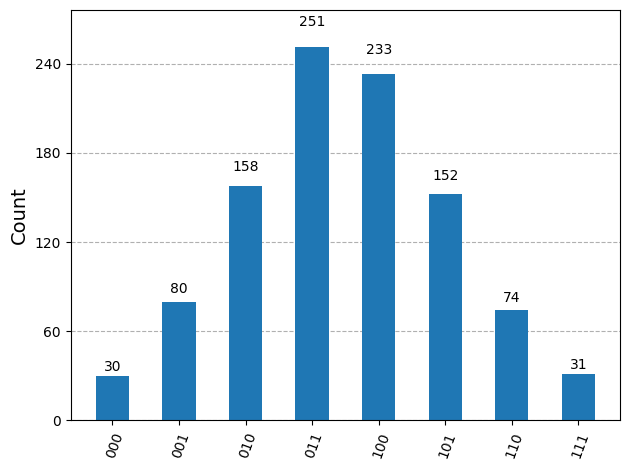

In [2]:
num_qubits = 3
nbins = 2**num_qubits

def sample_dist(_size, _nbins):
    _range = 0.25
    _sample = SingleGaussian(mean = 0.0, sd = 0.1,shots = _size)
    return RangeBinning(_sample, _nbins = _nbins, _range = (-_range, _range))
    #return MinMaxBinning(_sample, _nbins = _nbins)

sample = sample_dist(2**10, nbins)
print(sample)
plot_histogram(sample)

# QGAN networks

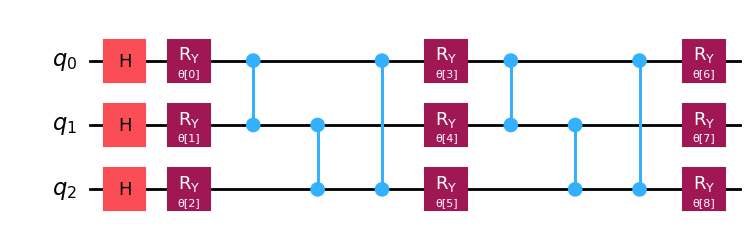

In [3]:
from qiskit.circuit import ParameterVector

reps = 2
qc = QuantumCircuit(num_qubits)
qc.h(range(num_qubits))
theta = ParameterVector("θ", length = (reps + 1) * num_qubits * 2)

p = 0

for q in range(num_qubits):
        qc.ry(theta[q], q)
        p += 1
for r in range(reps):

    for q in range(num_qubits):
        qc.cz(q%num_qubits, (q + 1)%num_qubits)
    for q in range(num_qubits):
        qc.ry(theta[p], q)
        p += 1
        
    

qc.draw("mpl")

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer, LeakyReLU

discriminator = Sequential([
    InputLayer(shape=(nbins,)),
    Dense(50),
    LeakyReLU(),
    Dense(1, activation='sigmoid') 
])

discriminator.summary()

2026-05-08 10:23:50.650661: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 501 (1.96 KB)

 Trainable params: 501 (1.96 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model = QGAN(num_qubits = num_qubits,
             generator = qc,
             discriminator = discriminator,
             real_dist = sample_dist)

In [6]:
epochs = 2000
model.discriminator_lr = 1e-2
model.fit(epochs = epochs, shots = 2**10, step_balance = 5/1, manager = True, opt = 'ADAM_PSR', lr = 1e-3)

Monitoring run: run_20260508_102350
Training started


100%|██████████| 2000/2000 [14:50<00:00,  2.25it/s]

Training completed


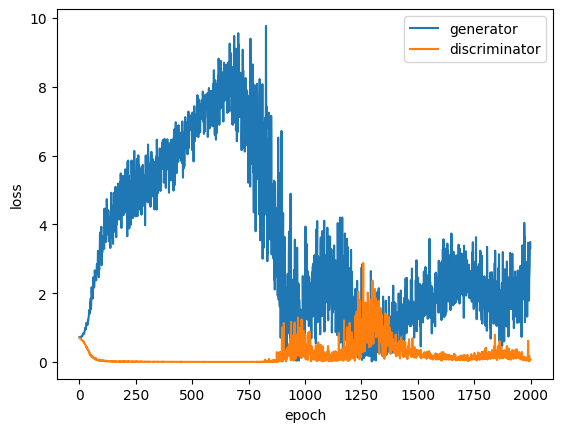

In [7]:
plt.plot(model.generator_losses, label = 'generator')
plt.plot(model.discriminator_losses, label = 'discriminator')
plt.legend()
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()